In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2

# 1. Converting Images to Batched tensors

An image is made up of pixel arrays that represent the intensity of pixels in grayscale or the color values in RGB format. When working with deep learning models, it's often necessary to convert these images into tensors, which are the primary data structures used in PyTorch for handling and processing data.

* **Tensors**: In PyTorch, tensors are multi-dimensional arrays similar to NumPy arrays, but with additional capabilities for GPU acceleration and automatic differentiation. Tensors are the fundamental building blocks for representing data and parameters in neural networks.
* **Batches**: Batching is a technique where multiple data samples (images, in this case) are grouped together into a single tensor. This allows efficient processing of multiple samples simultaneously, to take advantage of the parallel processing capabilities of modern hardware.


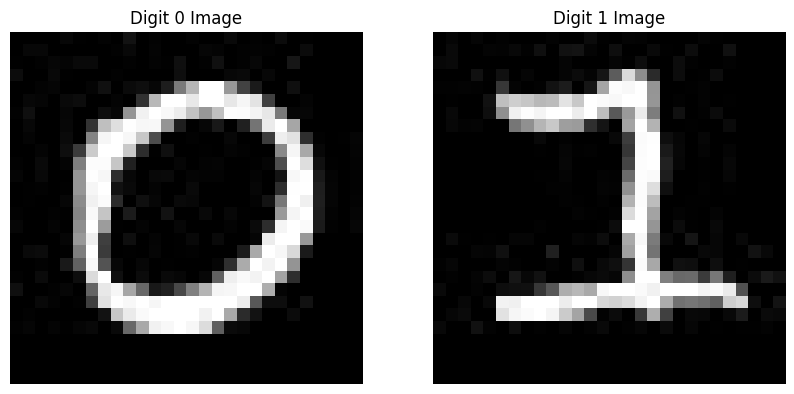

In [11]:
digit_0_array_og = cv2.imread("mnist_0.jpg")
digit_1_array_og = cv2.imread("mnist_1.jpg")

digit_0_array_gray = cv2.imread("mnist_0.jpg",cv2.IMREAD_GRAYSCALE )
digit_1_array_gray = cv2.imread("mnist_1.jpg",cv2.IMREAD_GRAYSCALE )

# Visualize the image

fig, axs = plt.subplots(1,2, figsize=(10,5))


axs[0].imshow(digit_0_array_og, cmap='gray',interpolation='none')
axs[0].set_title("Digit 0 Image")
axs[0].axis('off')

axs[1].imshow(digit_1_array_og, cmap="gray", interpolation = 'none')
axs[1].set_title("Digit 1 Image")
axs[1].axis('off')

plt.show()

In [12]:
print("Image array shape: ",digit_0_array_og.shape)
print(f"Min pixel value:{np.min(digit_0_array_og)} ; Max pixel value : {np.max(digit_0_array_og)}")

Image array shape:  (28, 28, 3)
Min pixel value:0 ; Max pixel value : 255


In [13]:
digit_0_array_gray

array([[  0,   0,   0,   0,   7,   1,   0,   3,   0,  18,   0,   3,   0,
          0,   3,   0,   0,   9,   0,   2,   0,  11,   0,   1,   0,   0,
          0,   0],
       [  0,   7,   7,   0,   0,   0,   0,   0,   2,   8,   0,   4,   0,
          0,   0,   6,   4,   0,   2,   3,   2,   0,   0,  11,   0,   0,
          0,   0],
       [  1,   0,   2,   6,   4,   9,   9,   0,   0,   2,   0,   3,   1,
         15,   0,   2,  16,   0,   2,   7,   0,   0,  22,   0,   0,   0,
          0,   0],
       [ 12,   0,   0,   8,   1,   0,   0,   0,   2,   0,   0,   0,   0,
         14,   0,   0,   0,   7,   9,   0,   7,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   3,   5,   0,   0,   4,  16,   0,  10,  14,   6,  29,
        122, 182, 255, 255, 152,  66,  26,   0,   0,  15,   0,   0,   0,
          0,   0],
       [  0,   7,   5,   0,   9,  12,   0,   0,   4,   0,  49, 184, 255,
        255, 232, 255, 255, 231, 246, 227,  64,   0,   0,   4,   0,   0,
          0,   0],
       [  

torch.Size([28, 28, 3])
torch.Size([28, 28, 3])


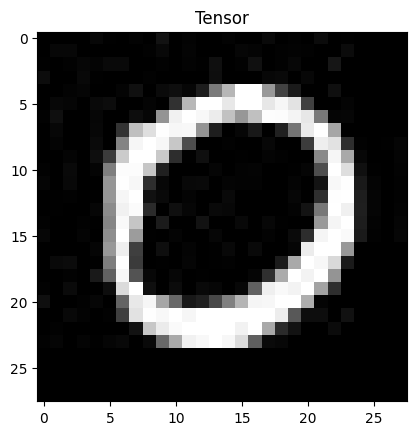

In [ ]:
#From numpy format to tensor format. Zero is black, one i white
img_tensor_0 = torch.tensor(digit_0_array_og, dtype=torch.float32) / 255
img_tensor_1 = torch.tensor(digit_1_array_og, dtype = torch.float32) / 255

print(img_tensor_0.shape)
print(img_tensor_1.shape)

plt.imshow(img_tensor_0)
plt.title('Tensor')
plt.show()

In [18]:
#Create the batch, remeber to use permute while batch to keep good format. Image tensors typically follow the shape convention [N ,C ,H ,W] unlike tensorflow which follows [N, H, W, C].
#Therefore, we need to bring the color channel to the second dimension.

batch_tensor = torch.stack([img_tensor_0, img_tensor_1]).permute(0,3,1,2)
batch_tensor.shape

torch.Size([2, 3, 28, 28])

## What is a Tensor?
A **tensor** in PyTorch is a **multi-dimensional array**, similar to a **NumPy array** but optimized for deep learning.

## When to Use Tensors?
- **Machine Learning & Deep Learning** tasks
- **GPU acceleration** for faster computations
- **Automatic differentiation** for training models

## Tensor Types:
- **Scalars (0D)** → `torch.tensor(5)`
- **Vectors (1D)** → `torch.tensor([1, 2, 3])`
- **Matrices (2D)** → `torch.tensor([[1, 2], [3, 4]])`
- **Higher dimensions (3D, 4D, etc.)** → Used in image, text, and audio processing

## Key Benefit:
PyTorch tensors can run on **CPUs and GPUs**, making them ideal for deep learning tasks.

In [20]:
a = torch.ones(5)
b = torch.ones(10)
c = torch.zeros(3)

print(a, b, c)

tensor([1., 1., 1., 1., 1.]) tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]) tensor([0., 0., 0.])


In [24]:
#Custom values of tensor
d = torch.tensor([1.,2.,3.,45.,6.,7.,8.,9.]).sort()
print(d)

torch.return_types.sort(
values=tensor([ 1.,  2.,  3.,  6.,  7.,  8.,  9., 45.]),
indices=tensor([0, 1, 2, 4, 5, 6, 7, 3]))


In [35]:
#More dimensions

tensors = []

e = torch.zeros(3,2)
tensors.append(e)
f = torch.ones(3,2)
tensors.append(f)
g = torch.tensor([[1.,2.],[3., 4.]])
tensors.append(g)
h = torch.tensor([[[1.,2.],[3., 4.]], [[5.,6.], [7.,8.]]])
tensors.append(h)

for i in tensors:
    print(f'The size of {i} tensor is {i.shape}')


The size of tensor([[0., 0.],
        [0., 0.],
        [0., 0.]]) tensor is torch.Size([3, 2])
The size of tensor([[1., 1.],
        [1., 1.],
        [1., 1.]]) tensor is torch.Size([3, 2])
The size of tensor([[1., 2.],
        [3., 4.]]) tensor is torch.Size([2, 2])
The size of tensor([[[1., 2.],
         [3., 4.]],

        [[5., 6.],
         [7., 8.]]]) tensor is torch.Size([2, 2, 2])


In [51]:
#Tensor extraction

#All
print(h[0:])

#First row
print(h[0,:])

#Last row
print(h[-1])

#All till 4 index
print(h[:4])

tensor([[[1., 2.],
         [3., 4.]],

        [[5., 6.],
         [7., 8.]]])
tensor([[1., 2.],
        [3., 4.]])
tensor([[5., 6.],
        [7., 8.]])
tensor([[[1., 2.],
         [3., 4.]],

        [[5., 6.],
         [7., 8.]]])


## Specify data type of elements

Whenever we create a tensor, PyTorch decides the data type of the elements of the tensor such that the data type can cover all the elements of the tensor. We can override this by specifying the data type while creating the tensor.

In [64]:
test_tensor = torch.tensor([[1,2,3], [4,5,6]])
print(test_tensor.dtype)
print(test_tensor)

#Because one was in float all will be recognized as float
test_tensor_float = torch.tensor([[1,2,3,4], [4.,5,6,7]])
print(test_tensor_float.dtype)
print(test_tensor_float)

#To change it use this
from_float_to_int = test_tensor_float.type(torch.int)
print(from_float_to_int)

torch.int64
tensor([[1, 2, 3],
        [4, 5, 6]])
torch.float32
tensor([[1., 2., 3., 4.],
        [4., 5., 6., 7.]])
tensor([[1, 2, 3, 4],
        [4, 5, 6, 7]], dtype=torch.int32)


## Arithmetic Operations on Tensors

In [65]:
tensor1 = torch.tensor([[1,2,3],[4,5,6]])
tensor2 = torch.tensor([[-1,2,-3],[4,-5,6]])

# Addition
print(tensor1+tensor2)
# We can also use
print(torch.add(tensor1,tensor2))

# Subtraction
print(tensor1-tensor2)
# We can also use
print(torch.sub(tensor1,tensor2))

# Multiplication
# Tensor with Scalar
print(tensor1 * 2)

# Tensor with another tensor
# Elementwise Multiplication
print(tensor1 * tensor2)

# Matrix multiplication
tensor3 = torch.tensor([[1,2],[3,4],[5,6]])
print(torch.mm(tensor1,tensor3))

# Division
# Tensor with scalar
print(tensor1/2)

# Tensor with another tensor
# Elementwise division
print(tensor1/tensor2)

tensor([[ 0,  4,  0],
        [ 8,  0, 12]])
tensor([[ 0,  4,  0],
        [ 8,  0, 12]])
tensor([[ 2,  0,  6],
        [ 0, 10,  0]])
tensor([[ 2,  0,  6],
        [ 0, 10,  0]])
tensor([[ 2,  4,  6],
        [ 8, 10, 12]])
tensor([[ -1,   4,  -9],
        [ 16, -25,  36]])
tensor([[22, 28],
        [49, 64]])
tensor([[0.5000, 1.0000, 1.5000],
        [2.0000, 2.5000, 3.0000]])
tensor([[-1.,  1., -1.],
        [ 1., -1.,  1.]])


## Broadcasting

   - `a` is a 1-dimensional tensor with shape \([ 3 ]\).
   - `b` is a scalar tensor with shape \([ 1 ]\).
   - When adding `a` and `b`, PyTorch broadcasts `b` to match the shape of `a`, resulting in \([ 1 + 4, 2 + 4, 3 + 4 ]\).


In [66]:
a = torch.tensor([1, 2, 3])
b = torch.tensor([4])

# adding a scalar to a vector
result = a + b

print("Result of Broadcasting:\n",result)

Result of Broadcasting:
 tensor([5, 6, 7])


In [67]:
a = torch.tensor([[1, 2, 3]])
b = torch.tensor([[4], [5], [6]])

# adding tensors of different shapes
result = a + b
print("Shape: ", result.shape)
print("\n")
print("Result of Broadcasting:\n", result)

Shape:  torch.Size([3, 3])


Result of Broadcasting:
 tensor([[5, 6, 7],
        [6, 7, 8],
        [7, 8, 9]])
